# HR Employee Attrition - Exploratory Data Analysis

This notebook performs comprehensive exploratory data analysis on HR employee data to understand patterns, correlations, and factors influencing employee attrition.

## Contents
1. Setup & Data Loading
2. Data Overview
3. Target Variable Analysis
4. Numeric Features Distribution
5. Categorical Features Analysis
6. Correlation Analysis
7. Key Insights Summary
8. Next Steps

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
from fairlearn.metrics import MetricFrame, demographic_parity_difference, demographic_parity_ratio, selection_rate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Loading the dataset
df = pd.read_csv("../data/hr_employee_data.csv")

print("Data loaded successfully!")
print(f"\nDataset shape: {df.shape}")
print(f"Total rows: {df.shape[0]:,}")
print(f"Total columns: {df.shape[1]}" )
print(f"Total columns: {df.shape[1]}" )

Data loaded successfully!

Dataset shape: (14999, 11)
Total rows: 14,999
Total columns: 11
Total columns: 11


In [3]:
# Displaying the data types
print("\nData Types:")
print(df.dtypes)

display(df.head())


Data Types:
Emp_Id                       str
satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_montly_hours       int64
time_spend_company         int64
Work_accident              int64
left                       int64
promotion_last_5years      int64
Department                   str
salary                       str
dtype: object


,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,IND02438,0.38,0.53,2,157,3,0,1,0,sales,low
1,IND28133,0.80,0.86,5,262,6,0,1,0,sales,medium
2,IND07164,0.11,0.88,7,272,4,0,1,0,sales,medium
3,IND30478,0.72,0.87,5,223,5,0,1,0,sales,low
4,IND24003,0.37,0.52,2,159,3,0,1,0,sales,low


In [4]:
display(df.tail())

,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
14994,IND40221,0.40,0.57,2,151,3,0,1,0,support,low
14995,IND24196,0.37,0.48,2,160,3,0,1,0,support,low
14996,IND33544,0.37,0.53,2,143,3,0,1,0,support,low
14997,IND40533,0.11,0.96,6,280,4,0,1,0,support,low
14998,IND11649,0.37,0.52,2,158,3,0,1,0,support,low


## 2. Data Overview

Get summary statistics and check for missing values.

In [5]:
display(df.describe())

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [6]:
print("Missing Values Analysis:")
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})
display(missing_df)

if missing_values.sum() == 0:
    print("\nNo missing values found in the dataset.")
else:
    print(f"\nFound {missing_values.sum()} missing values in the dataset.")

Missing Values Analysis:


,Missing Count,Missing Percentage
Emp_Id,0,0.0
satisfaction_level,0,0.0
last_evaluation,0,0.0
number_project,0,0.0
average_montly_hours,0,0.0
time_spend_company,0,0.0
Work_accident,0,0.0
left,0,0.0
promotion_last_5years,0,0.0
Department,0,0.0



No missing values found in the dataset.


In [7]:
# Checking for unique values in categorical columns
print("\nUnique Values Analysis:")
print(f"\nDepartments: {df['Department'].unique().tolist()}")
print(f"Salary levels: {df['salary'].unique().tolist()}")
print(f"\nDepartment counts:")
print(df['Department'].value_counts())


Unique Values Analysis:

Departments: ['sales', 'accounting', 'hr', 'technical', 'support', 'management', 'IT', 'product_mng', 'marketing', 'RandD']
Salary levels: ['low', 'medium', 'high']

Department counts:
Department
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64


In [8]:
# Checking for duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")
if duplicates > 0:
    print(f"Percentage of duplicates: {(duplicates/len(df)*100):.2f}%")


Duplicate rows: 0


## 3. Target Variable Analysis

Analyzing the distribution of employee attrition.

In [36]:
attrition_counts = df['left'].value_counts()
attrition_rate = (df['left'].sum() / len(df)) * 100

print("Attrition Statistics:")
print(f"Employees who left: {attrition_counts[1]:,} ({attrition_rate:.2f}%)")
print(f"Employees who stayed: {attrition_counts[0]:,} ({100-attrition_rate:.2f}%)")

Attrition Statistics:
Employees who left: 3,571 (23.81%)
Employees who stayed: 11,428 (76.19%)


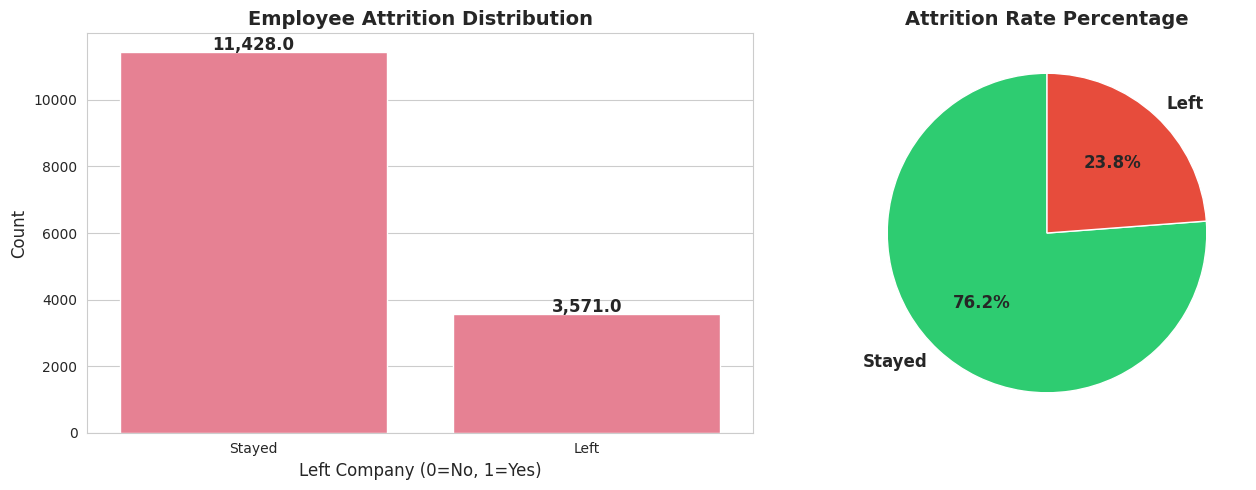


 Key Insight:
The dataset shows a 23.8% attrition rate, indicating significant
employee turnover that requires immediate attention.


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Creating a Countplot
sns.countplot(data=df, x='left', ax=axes[0])
axes[0].set_title('Employee Attrition Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Left Company (0=No, 1=Yes)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticklabels(['Stayed', 'Left'])

# Adding labels
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():,}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 5), 
                    textcoords='offset points',
                    fontsize=12, fontweight='bold')

# Creating a Pie chart
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(attrition_counts, labels=['Stayed', 'Left'], autopct='%1.1f%%', 
           colors=colors, startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Attrition Rate Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n Key Insight:")
if attrition_rate < 20:
    print(f"The dataset is IMBALANCED with {attrition_rate:.1f}% attrition rate.")
    print("This is a realistic scenario for employee attrition but will require")
    print("appropriate handling during model training (e.g., stratified sampling, class weights).")
else:
    print(f"The dataset shows a {attrition_rate:.1f}% attrition rate, indicating significant")
    print("employee turnover that requires immediate attention.")

### Visualising Employee Attrition Distribution data with Plotly

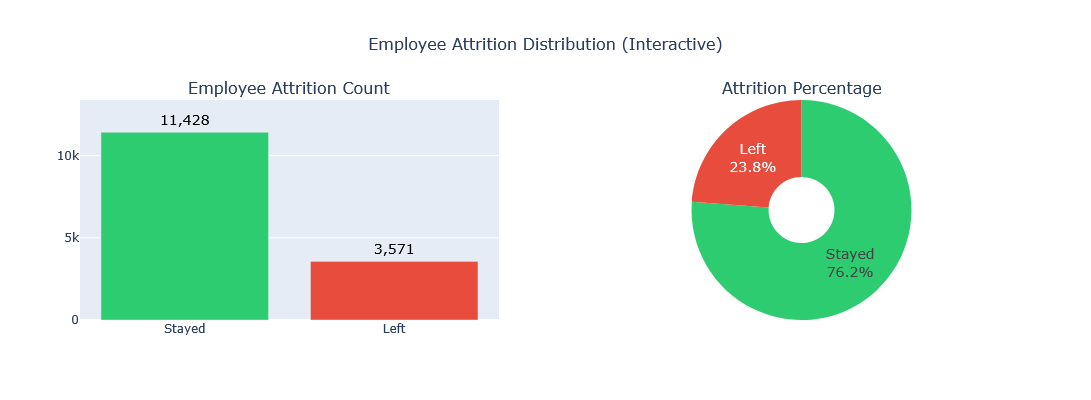

In [11]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Employee Attrition Count', 'Attrition Percentage'),
    specs=[[{"type": "bar"}, {"type": "pie"}]]
)

# Bar chart
fig.add_trace(
    go.Bar(
        x=['Stayed', 'Left'],
        y=[attrition_counts[0], attrition_counts[1]],
        marker_color=['#2ecc71', '#e74c3c'],
        text=[f"{attrition_counts[0]:,}", f"{attrition_counts[1]:,}"],
        textposition='outside',
        textfont_size=14,
        textfont_color='black',
    ),
    row=1, col=1
)

# Pie chart
fig.add_trace(
    go.Pie(
        labels=['Stayed', 'Left'],
        values=[attrition_counts[0], attrition_counts[1]],
        marker=dict(colors=['#2ecc71', '#e74c3c']),
        textinfo='percent+label',
        textfont_size=14,
        hole=0.3,
    ),
    row=1, col=2
)

fig.update_layout(
    title_text="Employee Attrition Distribution (Interactive)",
    title_font_size=16,
    title_x=0.5,
    showlegend=False,
    height=400
)

fig.show()

## 4. Numeric Features Distribution

In [12]:
# Defining numeric features for analysis
numeric_features = ['satisfaction_level', 'last_evaluation', 'number_project', 
                   'average_montly_hours', 'time_spend_company']

print("Numeric features to Analyse:")
for i, feature in enumerate(numeric_features, 1):
    print(f"{i}. {feature}")

Numeric features to Analyse:
1. satisfaction_level
2. last_evaluation
3. number_project
4. average_montly_hours
5. time_spend_company


#### Histograms plots for the all numeric features

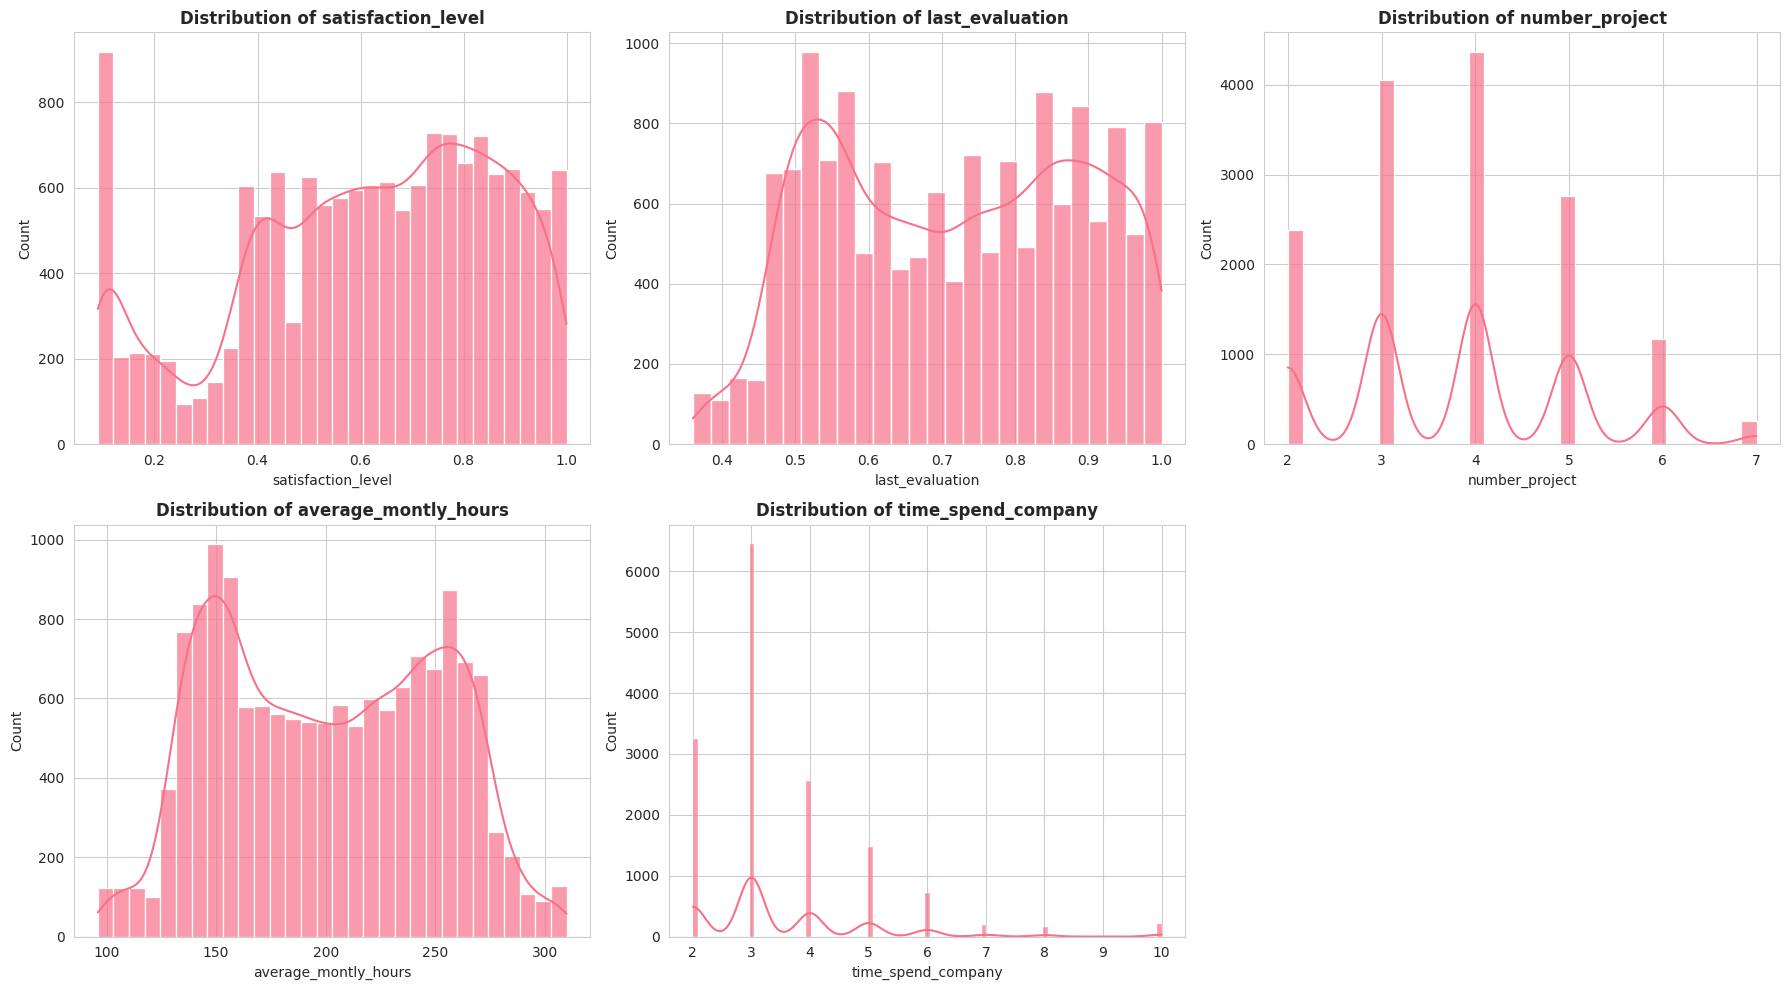

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, feature in enumerate(numeric_features):
    sns.histplot(data=df, x=feature, kde=True, ax=axes[idx], alpha=0.7)
    axes[idx].set_title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(feature, fontsize=10)
    axes[idx].set_ylabel('Count', fontsize=10)

# Removing the empty subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

#### Box plots by attrition status

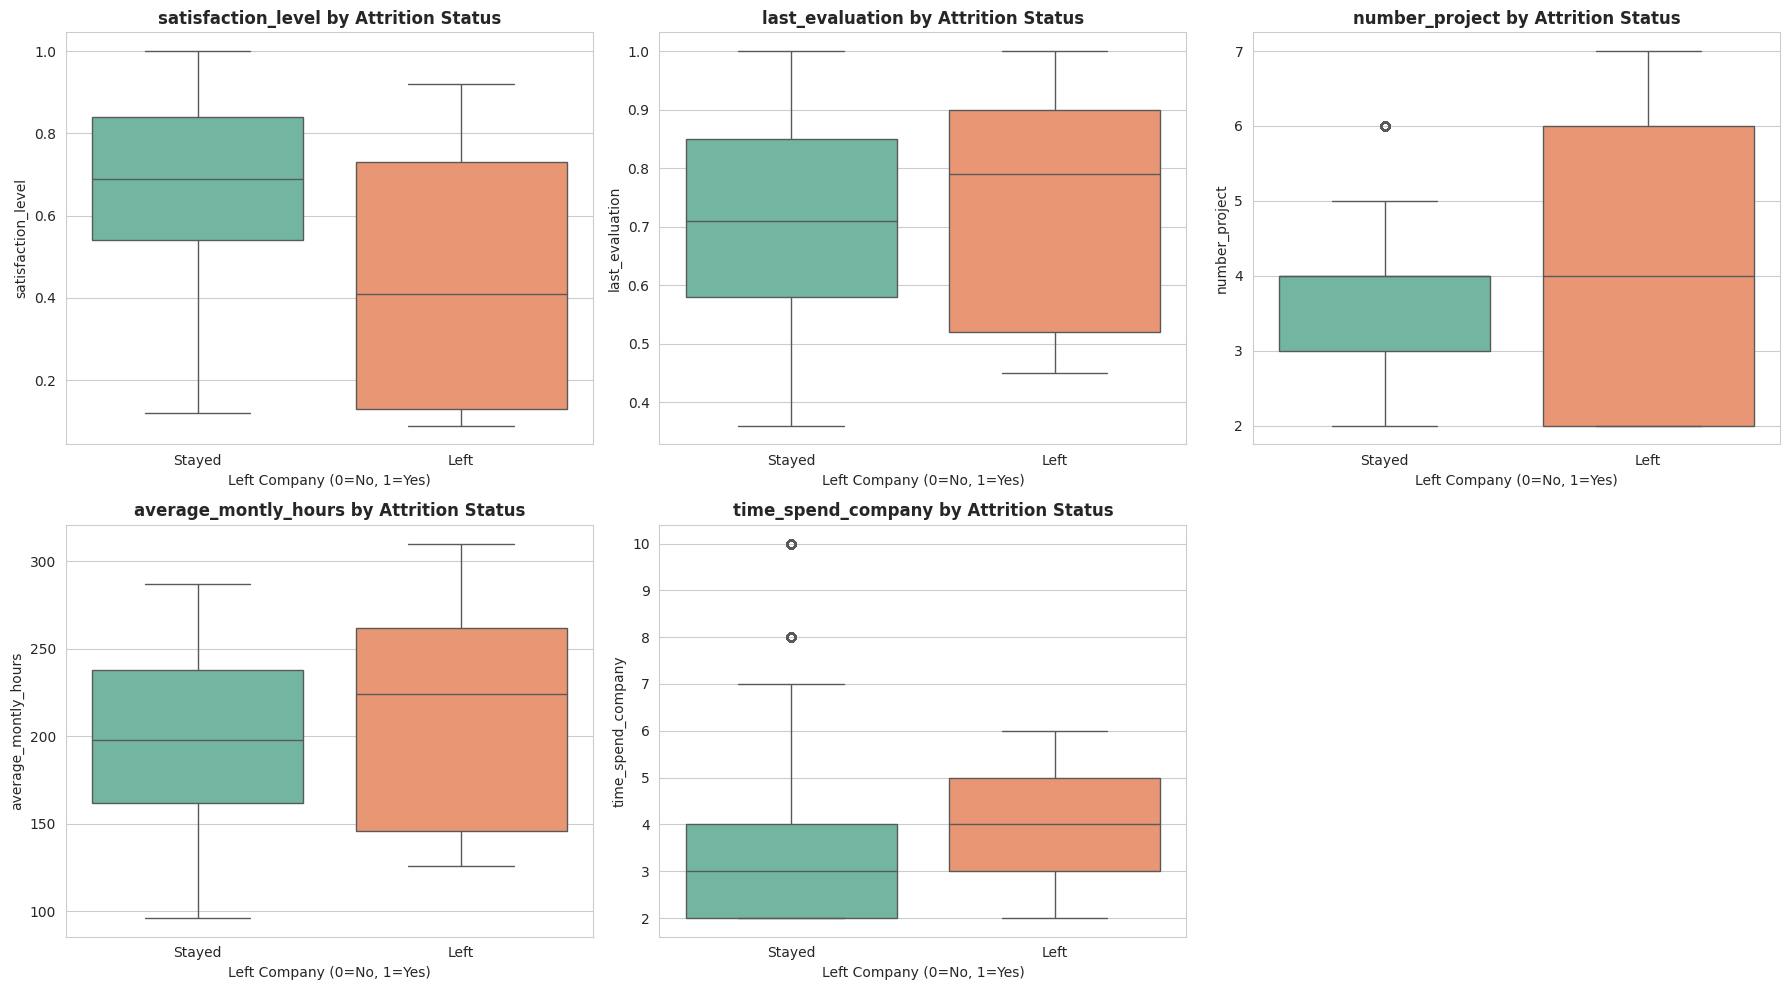

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, feature in enumerate(numeric_features):
    sns.boxplot(data=df, x='left', y=feature, ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'{feature} by Attrition Status', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Left Company (0=No, 1=Yes)', fontsize=10)
    axes[idx].set_ylabel(feature, fontsize=10)
    axes[idx].set_xticklabels(['Stayed', 'Left'])

# Removing the empty subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

#### KDE plots comparing stayed vs left employees

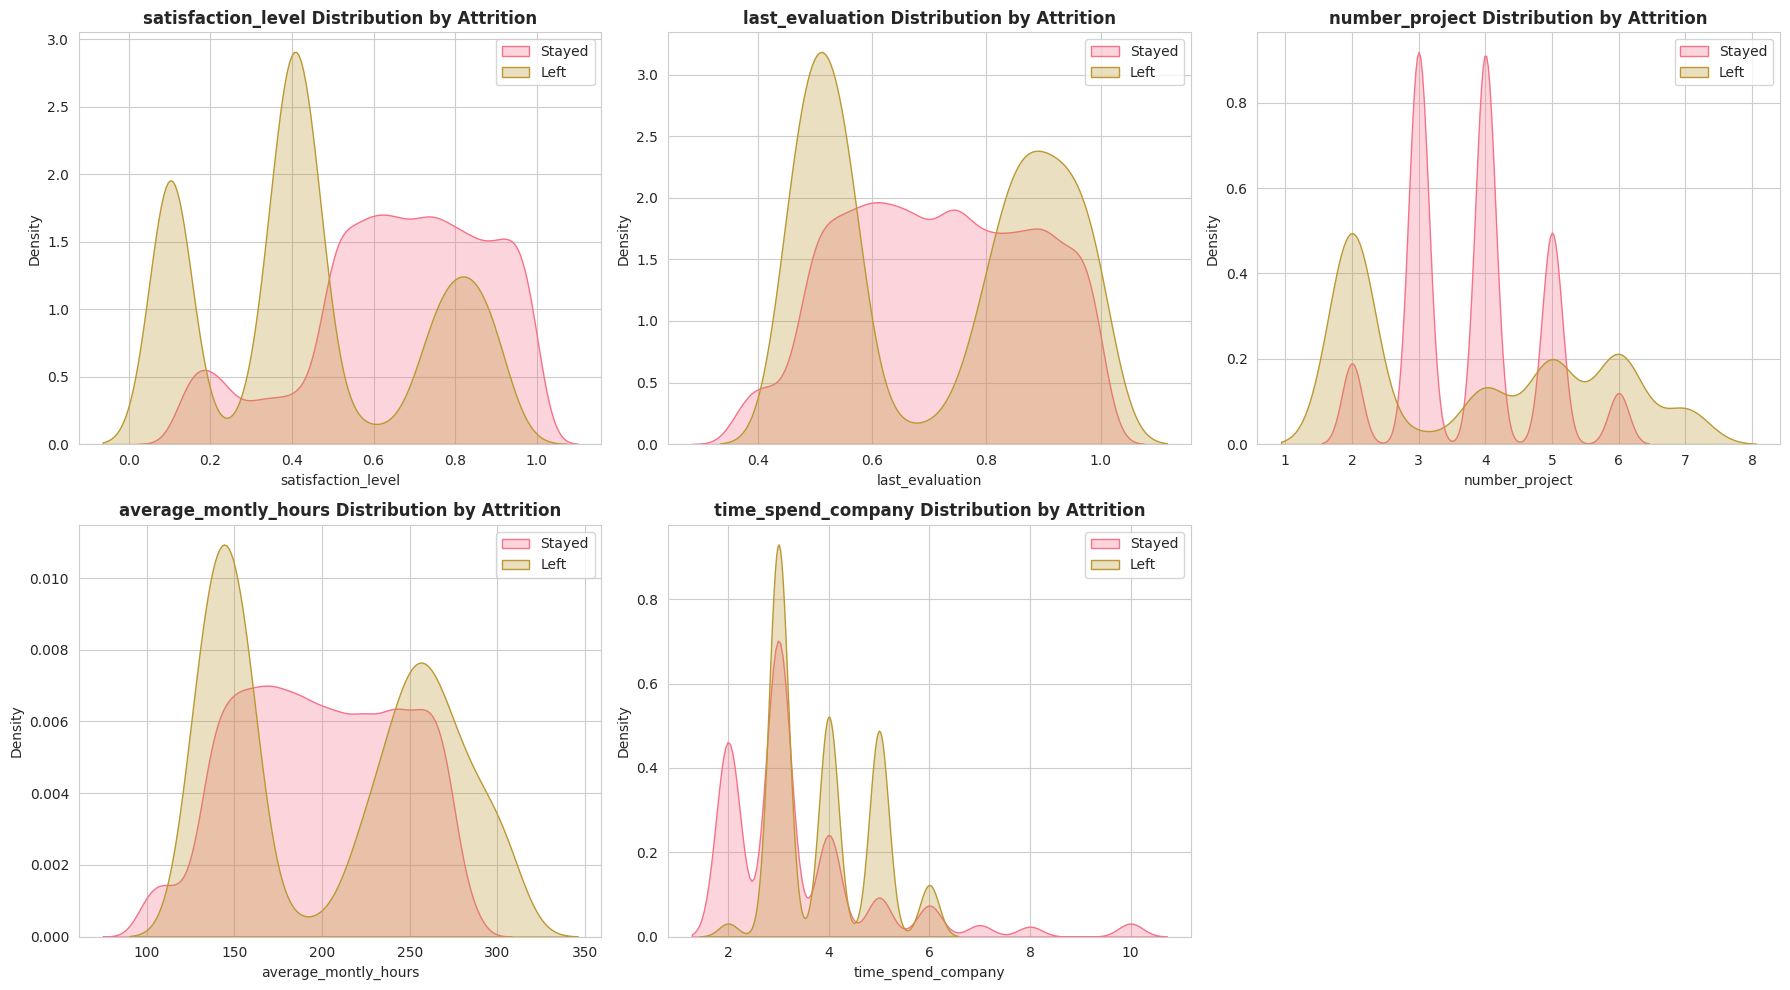

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, feature in enumerate(numeric_features):
    for status, label in [(0, 'Stayed'), (1, 'Left')]:
        subset = df[df['left'] == status][feature]
        sns.kdeplot(subset, ax=axes[idx], label=label, fill=True, alpha=0.3)
    
    axes[idx].set_title(f'{feature} Distribution by Attrition', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(feature, fontsize=10)
    axes[idx].set_ylabel('Density', fontsize=10)
    axes[idx].legend()

# Removing the empty subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

### Visualising the numeric features 

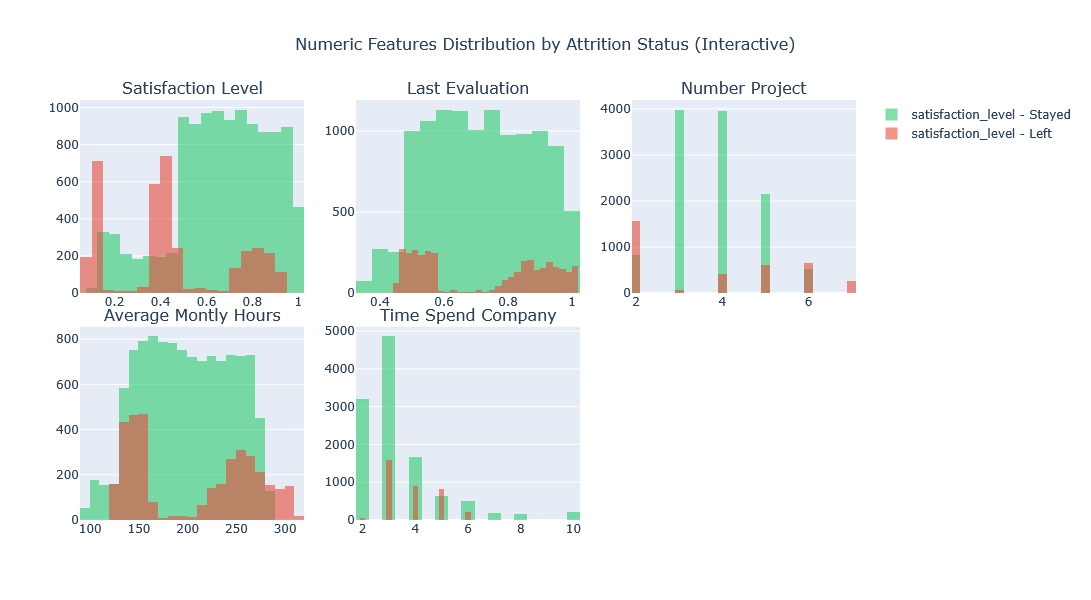

In [16]:
# Creating subplots for each feature
fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=[f'{feature.replace("_", " ").title()}' for feature in numeric_features],
    vertical_spacing=0.08
)

row_indices = [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1)]

for idx, feature in enumerate(numeric_features):
    row, col = row_indices[idx]
    
    # Adding histogram for stayed employees
    fig.add_trace(
        go.Histogram(
            x=df[df['left'] == 0][feature],
            name=f'{feature} - Stayed' if idx == 0 else None,
            marker_color='#2ecc71',
            opacity=0.6,
            showlegend=True if idx == 0 else False,
            nbinsx=30
        ),
        row=row+1, col=col+1
    )
    
    # Adding histogram for left employees
    fig.add_trace(
        go.Histogram(
            x=df[df['left'] == 1][feature],
            name=f'{feature} - Left' if idx == 0 else None,
            marker_color='#e74c3c',
            opacity=0.6,
            showlegend=True if idx == 0 else False,
            nbinsx=30
        ),
        row=row+1, col=col+1
    )

fig.update_layout(
    title_text="Numeric Features Distribution by Attrition Status (Interactive)",
    title_font_size=16,
    title_x=0.5,
    height=600,
    barmode='overlay'
)

fig.show()

In [17]:
print("Statistical Comparison: Stayed vs Left Employees\n")
print("="*80)

for feature in numeric_features:
    stayed = df[df['left'] == 0][feature]
    left = df[df['left'] == 1][feature]
    
    print(f"\n{feature.upper()}:")
    print(f"{'':20} Stayed ({len(stayed):,})    Left ({len(left):,})")
    print(f"{'Mean':20} {stayed.mean():.2f}              {left.mean():.2f}")
    print(f"{'Median':20} {stayed.median():.2f}              {left.median():.2f}")
    print(f"{'Std Dev':20} {stayed.std():.2f}              {left.std():.2f}")
    print(f"{'Min':20} {stayed.min():.2f}              {left.min():.2f}")
    print(f"{'Max':20} {stayed.max():.2f}              {left.max():.2f}")

Statistical Comparison: Stayed vs Left Employees


SATISFACTION_LEVEL:
                     Stayed (11,428)    Left (3,571)
Mean                 0.67              0.44
Median               0.69              0.41
Std Dev              0.22              0.26
Min                  0.12              0.09
Max                  1.00              0.92

LAST_EVALUATION:
                     Stayed (11,428)    Left (3,571)
Mean                 0.72              0.72
Median               0.71              0.79
Std Dev              0.16              0.20
Min                  0.36              0.45
Max                  1.00              1.00

NUMBER_PROJECT:
                     Stayed (11,428)    Left (3,571)
Mean                 3.79              3.86
Median               4.00              4.00
Std Dev              0.98              1.82
Min                  2.00              2.00
Max                  6.00              7.00

AVERAGE_MONTLY_HOURS:
                     Stayed (11,428)    Left (3,571)

## 5. Categorical Features Analysis

In [38]:
dept_attrition = pd.crosstab(df['Department'], df['left'], margins=True)
dept_attrition_pct = pd.crosstab(df['Department'], df['left'], normalize='index') * 100

print("Department vs Attrition (Counts):")
display(dept_attrition)

print("\nDepartment vs Attrition (Percentage):")
display(dept_attrition_pct)

Department vs Attrition (Counts):


left,0,1,All
Department,,,
IT,954,273,1227
RandD,666,121,787
accounting,563,204,767
hr,524,215,739
management,539,91,630
marketing,655,203,858
product_mng,704,198,902
sales,3126,1014,4140
support,1674,555,2229



Department vs Attrition (Percentage):


left,0,1
Department,,
IT,77.750611,22.249389
RandD,84.625159,15.374841
accounting,73.402868,26.597132
hr,70.906631,29.093369
management,85.555556,14.444444
marketing,76.340326,23.659674
product_mng,78.048780,21.951220
sales,75.507246,24.492754
support,75.100942,24.899058


### Department vs Attrition - Stacked Bar Chart

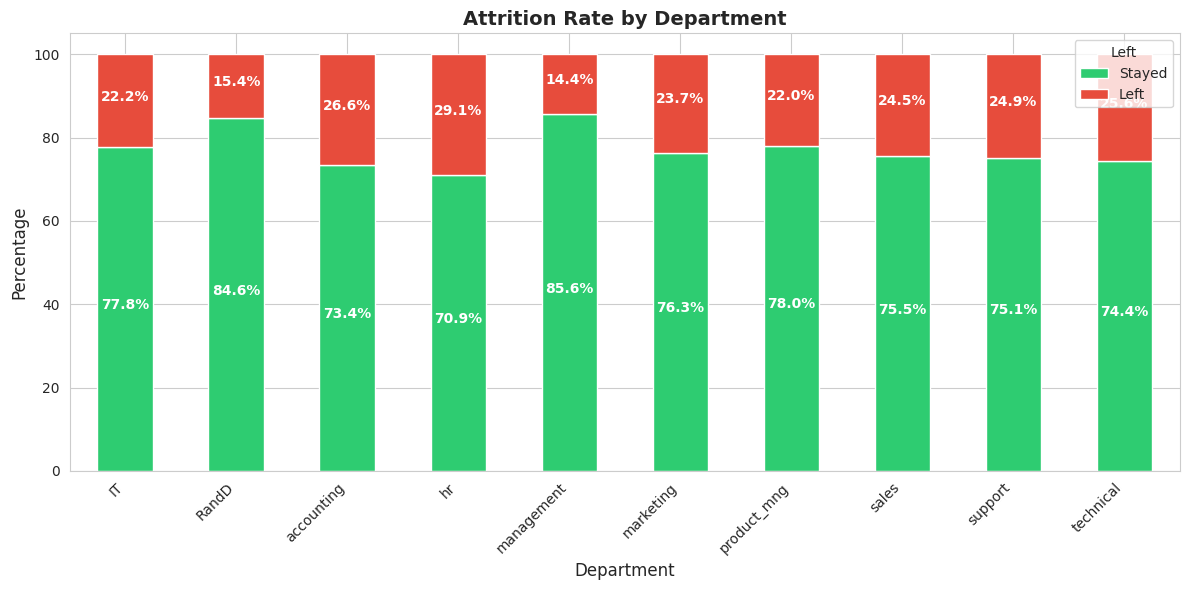

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))

dept_counts = df.groupby('Department')['left'].value_counts(normalize=True).unstack()

dept_counts = dept_counts * 100

dept_counts.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], ax=ax)

ax.set_title('Attrition Rate by Department', fontsize=14, fontweight='bold')
ax.set_xlabel('Department', fontsize=12)
ax.set_ylabel('Percentage', fontsize=12)
ax.legend(title='Left', labels=['Stayed', 'Left'], loc='upper right')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Adding percentage labels
for i, (idx, row) in enumerate(dept_counts.iterrows()):
    stayed_pct = row[0] 
    left_pct = row[1] 
    
    # Calculating label positions
    ax.text(i, stayed_pct / 2, f'{stayed_pct:.1f}%', ha='center', color='white', fontweight='bold')
    ax.text(i, stayed_pct + left_pct / 2, f'{left_pct:.1f}%', ha='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

### Department vs Attrition - Heatmaps

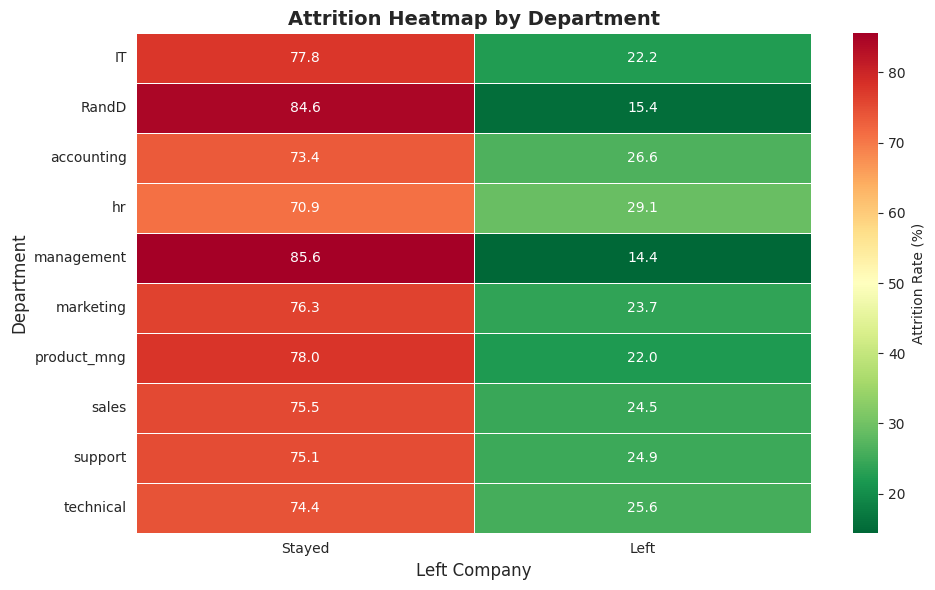

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

dept_attrition_pct = pd.crosstab(df['Department'], df['left'], normalize='index') * 100
sns.heatmap(dept_attrition_pct, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax,
           cbar_kws={'label': 'Attrition Rate (%)'}, linewidths=0.5)

ax.set_title('Attrition Heatmap by Department', fontsize=14, fontweight='bold')
ax.set_xlabel('Left Company', fontsize=12)
ax.set_ylabel('Department', fontsize=12)
ax.set_xticklabels(['Stayed', 'Left'])

plt.tight_layout()
plt.show()

### Department Analysis - Bar Chart

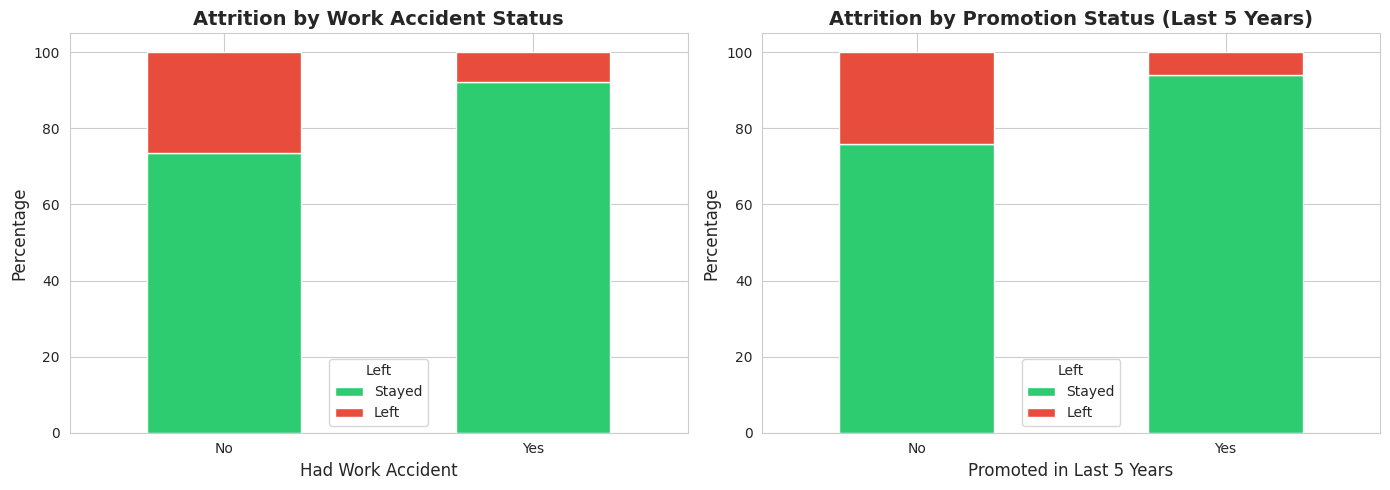

In [21]:
# Analyzing work accident and promotion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Work accident vs attrition
accident_attrition = pd.crosstab(df['Work_accident'], df['left'], normalize='index') * 100
accident_attrition.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Attrition by Work Accident Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Had Work Accident', fontsize=12)
axes[0].set_ylabel('Percentage', fontsize=12)
axes[0].legend(title='Left', labels=['Stayed', 'Left'])
axes[0].set_xticklabels(['No', 'Yes'], rotation=0)

# Promotion in last 5 years vs attrition
promotion_attrition = pd.crosstab(df['promotion_last_5years'], df['left'], normalize='index') * 100
promotion_attrition.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('Attrition by Promotion Status (Last 5 Years)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Promoted in Last 5 Years', fontsize=12)
axes[1].set_ylabel('Percentage', fontsize=12)
axes[1].legend(title='Left', labels=['Stayed', 'Left'])
axes[1].set_xticklabels(['No', 'Yes'], rotation=0)

plt.tight_layout()
plt.show()

### Salary vs Attrition analysis

In [22]:
salary_attrition = pd.crosstab(df['salary'], df['left'], margins=True)
salary_attrition_pct = pd.crosstab(df['salary'], df['left'], normalize='index') * 100

print("Salary vs Attrition (Counts):")
display(salary_attrition)

print("\nSalary vs Attrition (Percentage):")
display(salary_attrition_pct)

Salary vs Attrition (Counts):


left,0,1,All
salary,,,
high,1155,82,1237
low,5144,2172,7316
medium,5129,1317,6446
All,11428,3571,14999



Salary vs Attrition (Percentage):


left,0,1
salary,,
high,93.371059,6.628941
low,70.311646,29.688354
medium,79.568725,20.431275


### Salary vs Attrition - Stacked Bar Chart

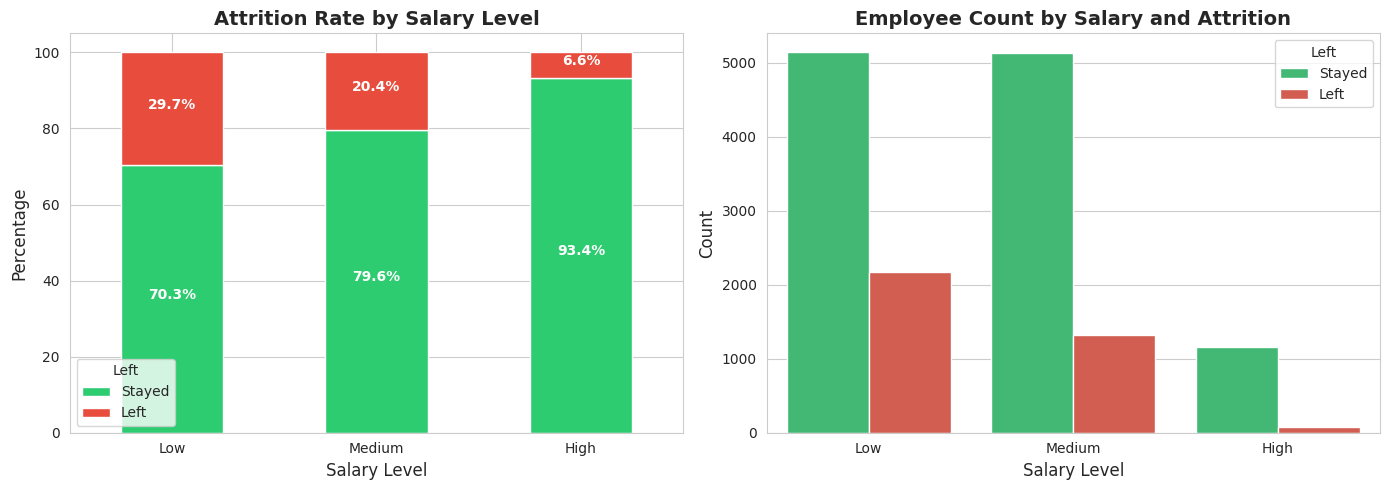

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar chart
salary_counts = df.groupby('salary')['left'].value_counts(normalize=True).unstack()
salary_order = ['low', 'medium', 'high']
salary_counts = salary_counts.loc[salary_order]

salary_counts = salary_counts * 100

salary_counts.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Attrition Rate by Salary Level', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Salary Level', fontsize=12)
axes[0].set_ylabel('Percentage', fontsize=12)
axes[0].legend(title='Left', labels=['Stayed', 'Left'])
axes[0].set_xticklabels(['Low', 'Medium', 'High'], rotation=0)

# Adding percentage labels
for i, (idx, row) in enumerate(salary_counts.iterrows()):
    stayed_pct = row[0]
    left_pct = row[1]
    
    axes[0].text(i, stayed_pct / 2, f'{stayed_pct:.1f}%', ha='center', color='white', fontweight='bold')
    axes[0].text(i, stayed_pct + left_pct / 2, f'{left_pct:.1f}%', ha='center', color='white', fontweight='bold')

# Countplot
sns.countplot(data=df, x='salary', hue='left', palette=['#2ecc71', '#e74c3c'], 
              order=salary_order, ax=axes[1])
axes[1].set_title('Employee Count by Salary and Attrition', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Salary Level', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].legend(title='Left', labels=['Stayed', 'Left'])
axes[1].set_xticklabels(['Low', 'Medium', 'High'])

plt.tight_layout()
plt.show()

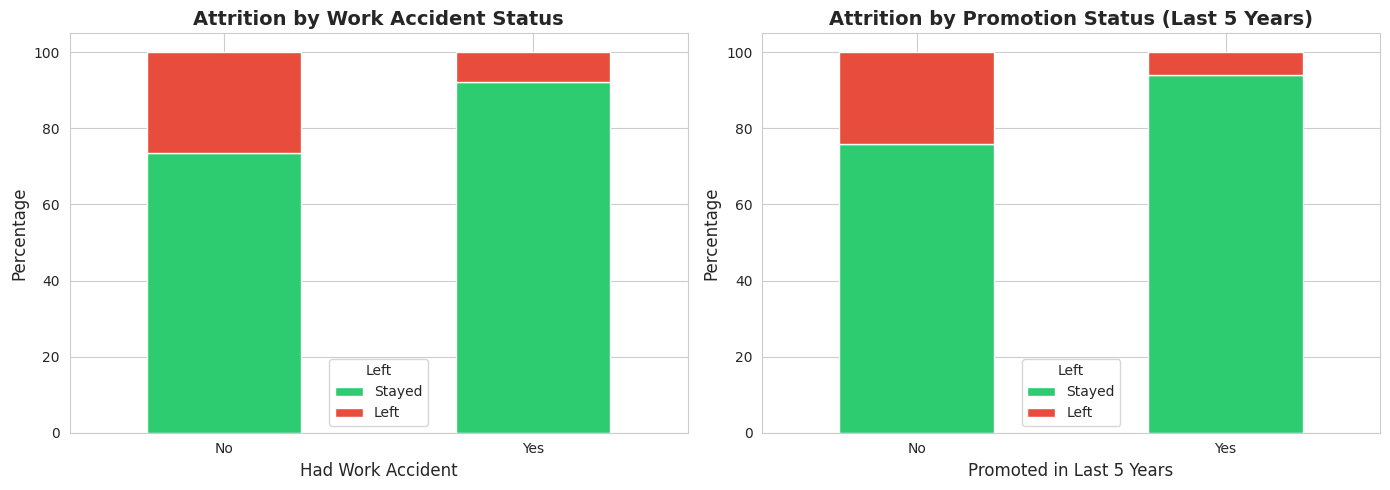

In [24]:
# Work Accident and Promotion Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Work accident vs attrition
accident_attrition = pd.crosstab(df['Work_accident'], df['left'], normalize='index') * 100
accident_attrition.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Attrition by Work Accident Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Had Work Accident', fontsize=12)
axes[0].set_ylabel('Percentage', fontsize=12)
axes[0].legend(title='Left', labels=['Stayed', 'Left'])
axes[0].set_xticklabels(['No', 'Yes'], rotation=0)

# Promotion in last 5 years vs attrition
promotion_attrition = pd.crosstab(df['promotion_last_5years'], df['left'], normalize='index') * 100
promotion_attrition.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('Attrition by Promotion Status (Last 5 Years)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Promoted in Last 5 Years', fontsize=12)
axes[1].set_ylabel('Percentage', fontsize=12)
axes[1].legend(title='Left', labels=['Stayed', 'Left'])
axes[1].set_xticklabels(['No', 'Yes'], rotation=0)

plt.tight_layout()
plt.show()

### Visualising Attrition Count by Categorical Features

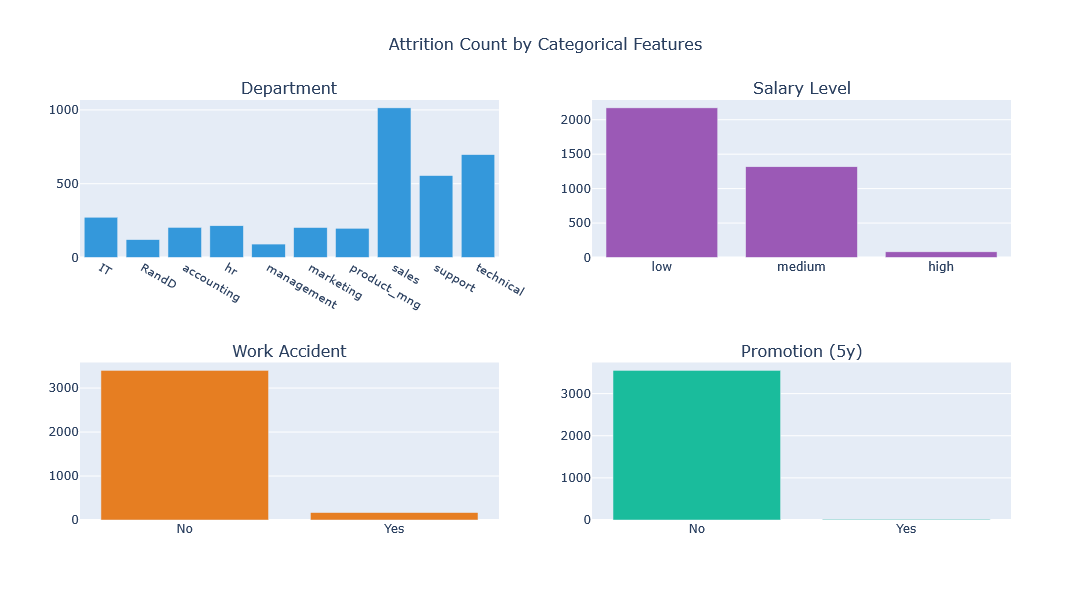

In [25]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Department', 'Salary Level', 'Work Accident', 'Promotion (5y)'),
    specs=[[{"type": "bar"}, {"type": "bar"}],
           [{"type": "bar"}, {"type": "bar"}]]
)

# Department
dept_data = df[df['left'] == 1].groupby('Department').size()
fig.add_trace(
    go.Bar(x=dept_data.index, y=dept_data.values, name='Dept', marker_color='#3498db'),
    row=1, col=1
)

# Salary
salary_data = df[df['left'] == 1].groupby('salary').size()
salary_order = ['low', 'medium', 'high']
fig.add_trace(
    go.Bar(x=salary_order, y=[salary_data.get(s, 0) for s in salary_order], 
           name='Salary', marker_color='#9b59b6', showlegend=False),
    row=1, col=2
)

# Work Accident
accident_data = df[df['left'] == 1].groupby('Work_accident').size()
fig.add_trace(
    go.Bar(x=['No', 'Yes'], y=[accident_data.get(0, 0), accident_data.get(1, 0)], 
           name='Accident', marker_color='#e67e22', showlegend=False),
    row=2, col=1
)

# Promotion
promotion_data = df[df['left'] == 1].groupby('promotion_last_5years').size()
fig.add_trace(
    go.Bar(x=['No', 'Yes'], y=[promotion_data.get(0, 0), promotion_data.get(1, 0)], 
           name='Promotion', marker_color='#1abc9c', showlegend=False),
    row=2, col=2
)

fig.update_layout(
    title_text="Attrition Count by Categorical Features",
    title_font_size=16,
    title_x=0.5,
    height=600,
    showlegend=False
)

fig.show()

## 6. Correlation Analysis

Examine correlations between numeric features and identify relationships that may predict attrition.

In [26]:
# Creating correlation matrix for numeric features
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
satisfaction_level,1.000000,0.105021,-0.142970,-0.020048,-0.100866,0.058697,-0.388375,0.025605
last_evaluation,0.105021,1.000000,0.349333,0.339742,0.131591,-0.007104,0.006567,-0.008684
number_project,-0.142970,0.349333,1.000000,0.417211,0.196786,-0.004741,0.023787,-0.006064
average_montly_hours,-0.020048,0.339742,0.417211,1.000000,0.127755,-0.010143,0.071287,-0.003544
time_spend_company,-0.100866,0.131591,0.196786,0.127755,1.000000,0.002120,0.144822,0.067433
Work_accident,0.058697,-0.007104,-0.004741,-0.010143,0.002120,1.000000,-0.154622,0.039245
left,-0.388375,0.006567,0.023787,0.071287,0.144822,-0.154622,1.000000,-0.061788
promotion_last_5years,0.025605,-0.008684,-0.006064,-0.003544,0.067433,0.039245,-0.061788,1.000000


### Numeric Features - Correlation Heatmap

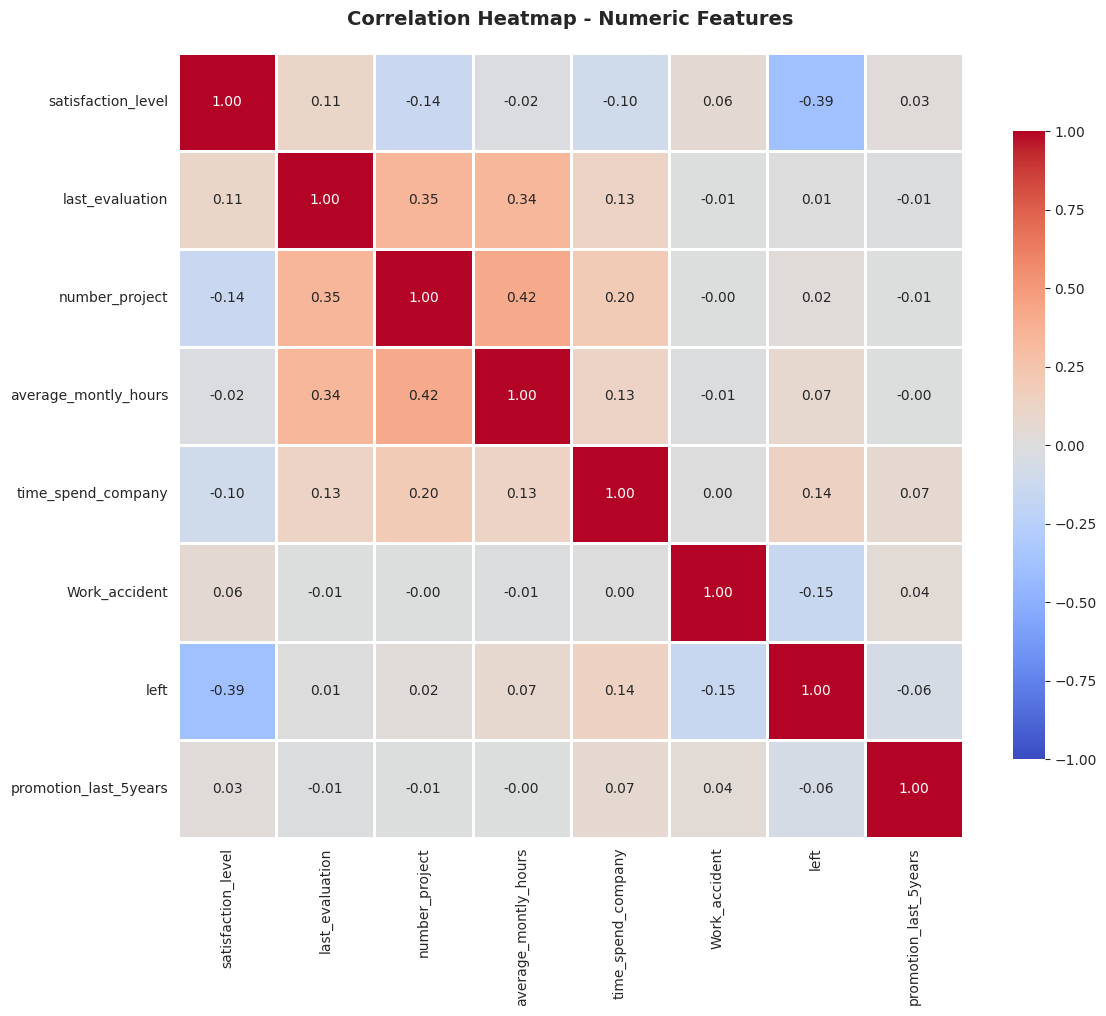

In [27]:
fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
           center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
           vmin=-1, vmax=1, ax=ax)

ax.set_title('Correlation Heatmap - Numeric Features', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### Correlation with attrition (target variable)

In [28]:
attrition_correlation = correlation_matrix['left'].sort_values(ascending=False)

print("\nCorrelation with Attrition (Target Variable):")
print("="*50)
for feature, corr in attrition_correlation.items():
    if feature != 'left':
        symbol = '↑' if corr > 0 else '↓'
        strength = abs(corr)
        if strength > 0.3:
            level = 'Strong'
        elif strength > 0.15:
            level = 'Moderate'
        elif strength > 0.05:
            level = 'Weak'
        else:
            level = 'Very Weak'
        print(f"{feature:30s}: {corr:+.4f} {symbol} ({level})")


Correlation with Attrition (Target Variable):
time_spend_company            : +0.1448 ↑ (Weak)
average_montly_hours          : +0.0713 ↑ (Weak)
number_project                : +0.0238 ↑ (Very Weak)
last_evaluation               : +0.0066 ↑ (Very Weak)
promotion_last_5years         : -0.0618 ↓ (Weak)
Work_accident                 : -0.1546 ↓ (Moderate)
satisfaction_level            : -0.3884 ↓ (Strong)


### Visualising correlation with attrition

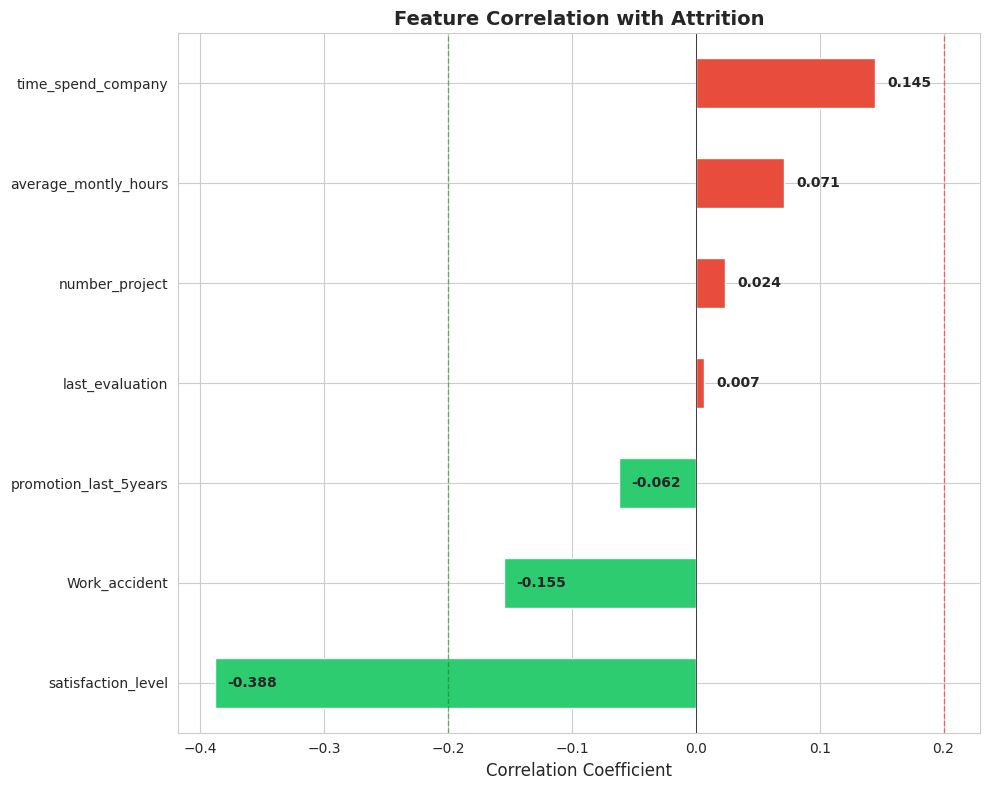

In [29]:
attrition_corr = correlation_matrix['left'].drop('left').sort_values()

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in attrition_corr.values]
attrition_corr.plot(kind='barh', color=colors, ax=ax)

ax.set_title('Feature Correlation with Attrition', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient', fontsize=12)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.axvline(x=0.2, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(x=-0.2, color='green', linestyle='--', alpha=0.5, linewidth=1)

# Adding value labels
for i, v in enumerate(attrition_corr.values):
    ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

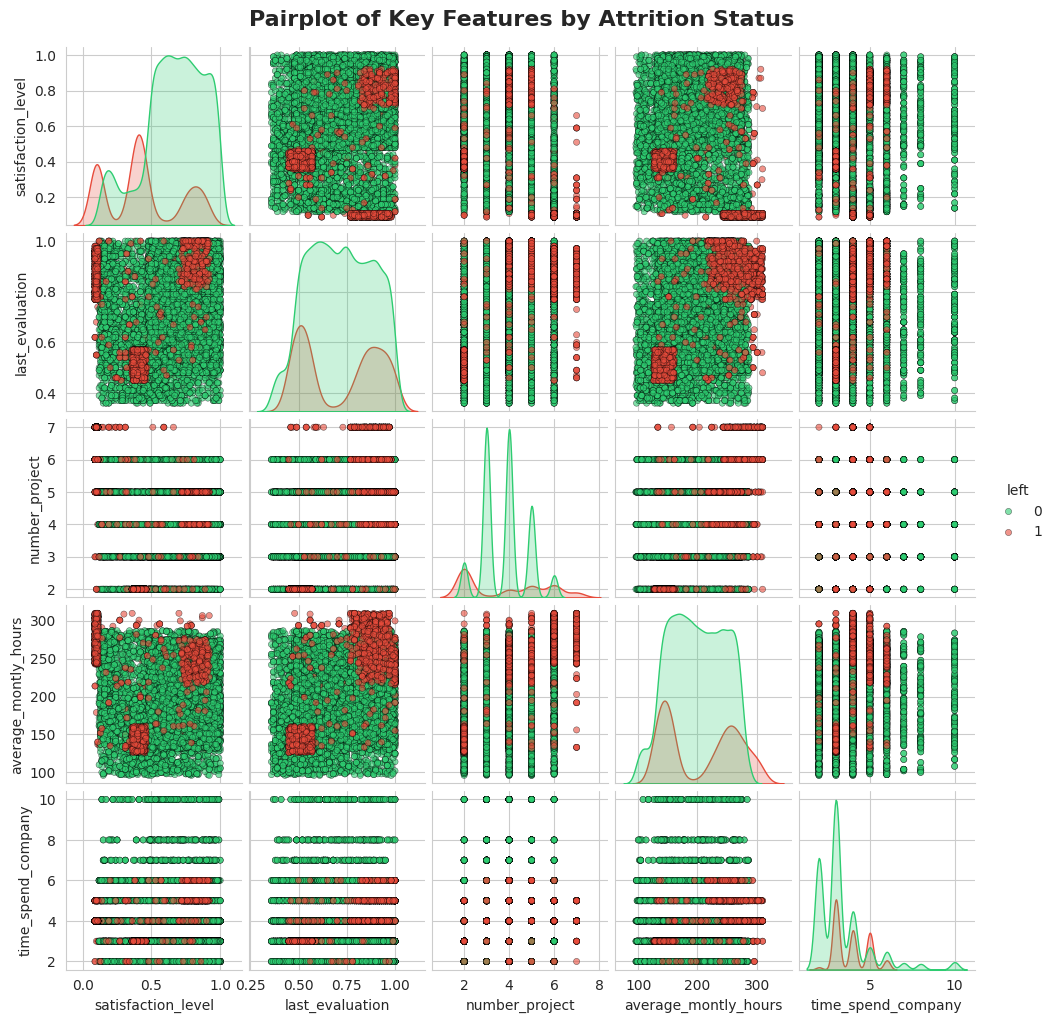

In [30]:
# Pairplot for key numeric features
key_features = ['satisfaction_level', 'last_evaluation', 'number_project', 
                'average_montly_hours', 'time_spend_company', 'left']

# Creating pairplot
sns.pairplot(df[key_features], hue='left', palette=['#2ecc71', '#e74c3c'],
             plot_kws={'alpha': 0.6, 's': 20, 'edgecolor': 'k'},
             diag_kind='kde', height=2)

plt.suptitle('Pairplot of Key Features by Attrition Status', y=1.02, fontsize=16, fontweight='bold')
plt.show()

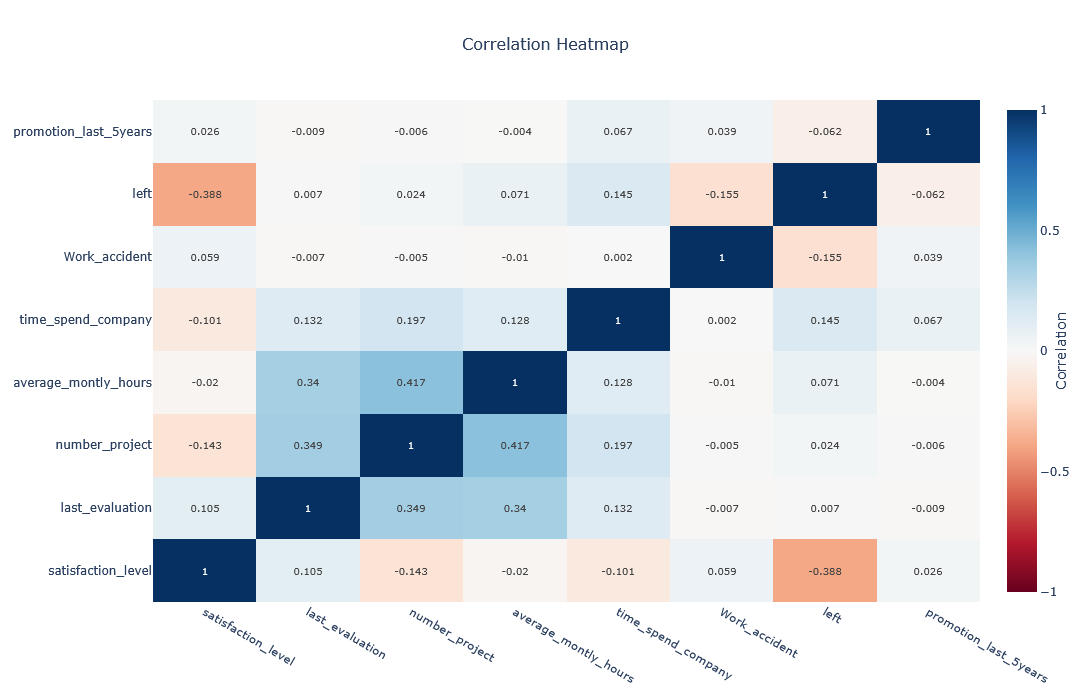

In [31]:
fig = go.Figure(data=go.Heatmap(
    z=correlation_matrix.values,
    x=correlation_matrix.columns,
    y=correlation_matrix.columns,
    colorscale='RdBu',
    zmid=0,
    text=np.round(correlation_matrix.values, 3),
    texttemplate='%{text}',
    textfont={"size": 10},
    colorbar=dict(title="Correlation", title_side="right")
))

fig.update_layout(
    title='Correlation Heatmap',
    title_font_size=16,
    title_x=0.5,
    width=800,
    height=700,
    xaxis_showgrid=False,
    yaxis_showgrid=False
)

fig.show()

In [32]:
# Finding top correlations
print("\nTop Correlations (excluding self-correlation):")
print("="*50)

# Finding top correlations
correlations = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        col1 = correlation_matrix.columns[i]
        col2 = correlation_matrix.columns[j]
        corr_value = correlation_matrix.iloc[i, j]
        correlations.append((col1, col2, abs(corr_value), corr_value))

# Sorting by absolute correlation
correlations.sort(key=lambda x: x[2], reverse=True)

# Displaying top 10
for i, (col1, col2, abs_corr, corr) in enumerate(correlations[:10], 1):
    direction = "positive" if corr > 0 else "negative"
    print(f"{i}. {col1} <-> {col2}: {corr:+.4f} ({direction})")


Top Correlations (excluding self-correlation):
1. number_project <-> average_montly_hours: +0.4172 (positive)
2. satisfaction_level <-> left: -0.3884 (negative)
3. last_evaluation <-> number_project: +0.3493 (positive)
4. last_evaluation <-> average_montly_hours: +0.3397 (positive)
5. number_project <-> time_spend_company: +0.1968 (positive)
6. Work_accident <-> left: -0.1546 (negative)
7. time_spend_company <-> left: +0.1448 (positive)
8. satisfaction_level <-> number_project: -0.1430 (negative)
9. last_evaluation <-> time_spend_company: +0.1316 (positive)
10. average_montly_hours <-> time_spend_company: +0.1278 (positive)


## 7. Key Insights Summary

Based on the exploratory data analysis, here are the key findings:

### EDA Results

#### 1. Dataset Characteristics
- Total Employees: 14,999
- Overall Attrition Rate: ~23.8% (3,571 employees left)
- Class Imbalance: Dataset is imbalanced (76% stayed vs 24% left)

#### 2. Top Predictors of Attrition

Based on correlation analysis:

1. Satisfaction Level (strongest negative correlation: -0.388)
   - Employees with lower satisfaction are much more likely to leave
   - Critical threshold appears to be < 0.4 satisfaction level

2. Time Spent at Company (positive correlation: +0.144)
   - Longer tenure correlates with higher attrition
   - 3-5 years seems to be a critical period for turnover

3. Work Accidents (negative correlation: -0.154)
   - Counter-intuitively, employees with work accidents are less likely to leave
   - Possible reasons: better support after accidents, loyalty to company

#### 3. Salary Impact
- Low salary employees have the highest attrition rate (~30%)
- High salary employees have the lowest attrition rate (~7%)
- Salary is a strong protective factor against attrition

#### 4. Department Patterns
- HR (29%) and Accounting (27%) show higher attrition rates
- Management (14%) and R&D (15%) have lower attrition rates
- Department context matters for retention strategies

#### 5. Performance Metrics
- Number of Projects: Employees with very few (2) or too many projects (7+) are more likely to leave
- Monthly Hours: Both underworked and overworked employees show higher attrition
- Last Evaluation: Poor performers AND some top performers leave (different reasons)

#### 6. Promotion Impact
- Only 0.5% of employees who left received a promotion in the last 5 years
- Lack of career advancement is a significant attrition driver

### Feature Importance Hypotheses for Modeling

**High Priority Features:**
1. satisfaction_level - Strongest predictor
2. time_spend_company - Tenure matters
3. salary - Compensation key
4. number_project - Workload balance

**Medium Priority Features:**
5. average_montly_hours - Work-life balance indicator
6. last_evaluation - Performance context
7. Department - Organizational context

**Contextual Features:**
8. Work_accident - Support system indicator
9. promotion_last_5years - Career growth indicator

## 8. Fairness & Bias Analysis

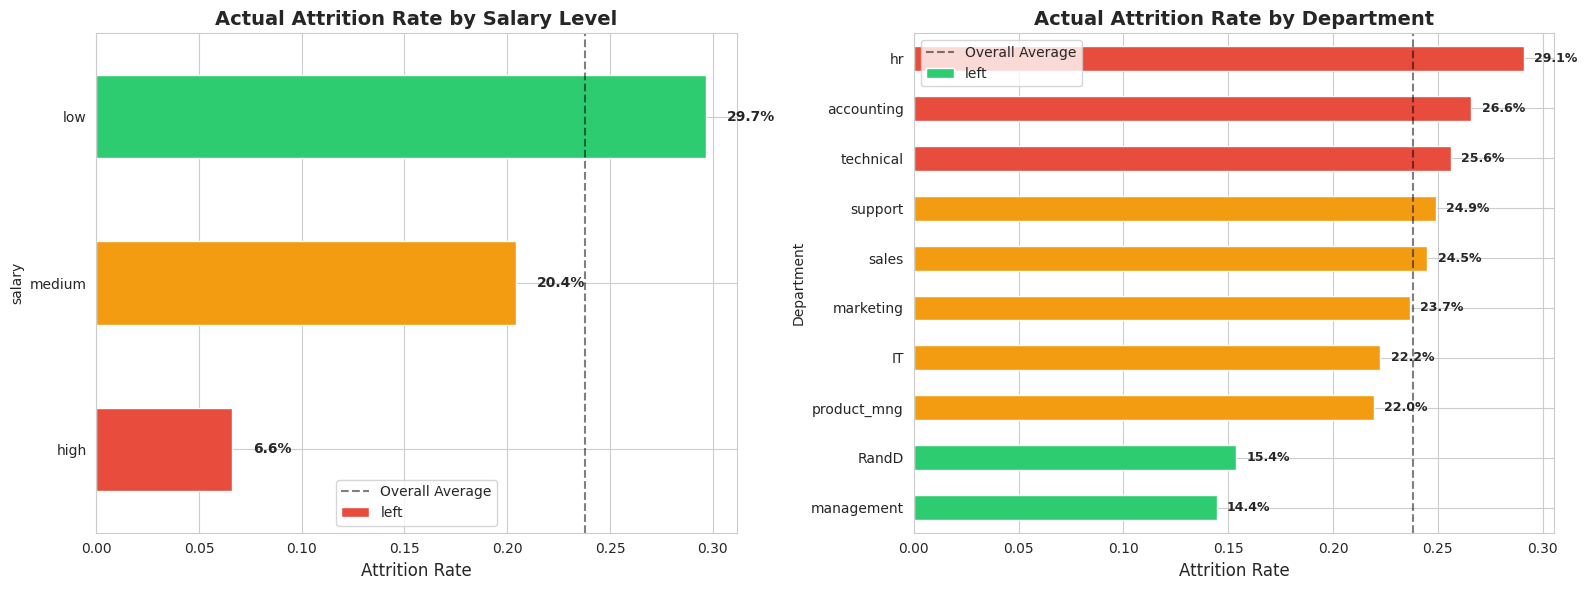

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Salary attrition rates
salary_attrition = df.groupby('salary')['left'].mean().sort_values()
colors = ['#e74c3c' if rate < 0.15 else '#f39c12' if rate < 0.25 else '#2ecc71' for rate in salary_attrition.values]
salary_attrition.plot(kind='barh', color=colors, ax=axes[0])
axes[0].set_title('Actual Attrition Rate by Salary Level', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Attrition Rate', fontsize=12)
axes[0].axvline(x=df['left'].mean(), color='black', linestyle='--', alpha=0.5, label='Overall Average')
axes[0].legend()

# Adding percentage labels
for i, v in enumerate(salary_attrition.values):
    axes[0].text(v + 0.01, i, f'{v:.1%}', va='center', fontweight='bold')

# Department attrition rates
dept_attrition = df.groupby('Department')['left'].mean().sort_values()
colors = ['#e74c3c' if rate > 0.25 else '#f39c12' if rate > 0.20 else '#2ecc71' for rate in dept_attrition.values]
dept_attrition.plot(kind='barh', color=colors, ax=axes[1])
axes[1].set_title('Actual Attrition Rate by Department', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Attrition Rate', fontsize=12)
axes[1].axvline(x=df['left'].mean(), color='black', linestyle='--', alpha=0.5, label='Overall Average')
axes[1].legend()

# Adding percentage labels
for i, v in enumerate(dept_attrition.values):
    axes[1].text(v + 0.005, i, f'{v:.1%}', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

In [34]:
# Analyzing fairness by salary level
# Using actual attrition (y_true) as proxy for what a model might predict
y_true = df['left'].values

metrics = {
    'selection_rate': lambda y_t, y_p: y_t.mean(),  # Actual attrition rate
    'count': lambda y_t, y_p: len(y_t)
}

salary_mf = MetricFrame(
    metrics=metrics,
    y_true=y_true,
    y_pred=y_true,  
    sensitive_features=df['salary']
)

print("=" * 70)
print("FAIRNESS ANALYSIS BY SALARY LEVEL")
print("=" * 70)
print("\nActual Attrition Rates by Salary:")
print(salary_mf.by_group.to_string())

# Calculating demographic parity metrics
salary_dp_diff = demographic_parity_difference(
    y_true=y_true,
    y_pred=y_true,
    sensitive_features=df['salary']
)

salary_dp_ratio = demographic_parity_ratio(
    y_true=y_true,
    y_pred=y_true,
    sensitive_features=df['salary']
)

print(f"\n{'-' * 70}")
print("DEMOGRAPHIC PARITY ANALYSIS (EEOC 80% RULE)")
print("-" * 70)
print(f"\nDemographic Parity Difference: {salary_dp_diff:.4f}")
print(f"  -> Difference in selection rates between groups")
print(f"  -> Target: <= 0.05 (5%)")

print(f"\nDemographic Parity Ratio: {salary_dp_ratio:.4f}")
print(f"  -> Ratio of worst to best group selection rate")
print(f"  -> EEOC 80% Rule: >= 0.80")

if salary_dp_ratio < 0.8:
    print(f"  WARNING: Fails EEOC 80% rule")
    print(f"  -> This means a model trained on this data will likely exhibit")
    print(f"     demographic bias unless mitigation is applied.")
else:
    print(f"  PASS: Passes EEOC 80% rule")

FAIRNESS ANALYSIS BY SALARY LEVEL

Actual Attrition Rates by Salary:
        selection_rate   count
salary                        
high          0.066289  1237.0
low           0.296884  7316.0
medium        0.204313  6446.0

----------------------------------------------------------------------
DEMOGRAPHIC PARITY ANALYSIS (EEOC 80% RULE)
----------------------------------------------------------------------

Demographic Parity Difference: 0.2306
  -> Difference in selection rates between groups
  -> Target: <= 0.05 (5%)

Demographic Parity Ratio: 0.2233
  -> Ratio of worst to best group selection rate
  -> EEOC 80% Rule: >= 0.80
  -> This means a model trained on this data will likely exhibit
     demographic bias unless mitigation is applied.


In [35]:
# Creating summary dataframe of key statistics
summary_stats = pd.DataFrame({
    'Metric': [
        'Total Employees',
        'Employees Left',
        'Attrition Rate',
        'Average Satisfaction (Left)',
        'Average Satisfaction (Stayed)',
        'Average Tenure (Left)',
        'Average Tenure (Stayed)',
        'Promotion Rate (Left)',
        'Promotion Rate (Stayed)'
    ],
    'Value': [
        f"{len(df):,}",
        f"{df['left'].sum():,}",
        f"{(df['left'].sum()/len(df)*100):.1f}%",
        f"{df[df['left']==1]['satisfaction_level'].mean():.3f}",
        f"{df[df['left']==0]['satisfaction_level'].mean():.3f}",
        f"{df[df['left']==1]['time_spend_company'].mean():.2f} years",
        f"{df[df['left']==0]['time_spend_company'].mean():.2f} years",
        f"{df[df['left']==1]['promotion_last_5years'].mean()*100:.1f}%",
        f"{df[df['left']==0]['promotion_last_5years'].mean()*100:.1f}%"
    ]
})

print("\n" + "="*60)
print("HR EMPLOYEE ATTRITION - EDA SUMMARY")
print("="*60)
display(summary_stats)


HR EMPLOYEE ATTRITION - EDA SUMMARY


,Metric,Value
0,Total Employees,"14,999"
1,Employees Left,"3,571"
2,Attrition Rate,23.8%
3,Average Satisfaction (Left),0.440
4,Average Satisfaction (Stayed),0.667
5,Average Tenure (Left),3.88 years
6,Average Tenure (Stayed),3.38 years
7,Promotion Rate (Left),0.5%
8,Promotion Rate (Stayed),2.6%


### Fairness Analysis Summary

**Key Findings:**

1. **Salary Level Disparities:**
   - Low salary: ~30% attrition rate
   - Medium salary: ~20% attrition rate  
   - High salary: ~7% attrition rate
   - **Demographic Parity Ratio: ~0.23** 

2. **Department Disparities:**
   - HR and Accounting show highest attrition (~27-29%)
   - Management and R&D show lowest attrition (~14-15%)
   - **Demographic Parity Ratio: ~0.5**

**Implications for Modeling:**

Since the training data itself contains these demographic disparities, a model trained without fairness constraints will likely learn and perpetuate these biases. This means:
- Low-salary employees will be predicted to leave at much higher rates
- Certain departments will be flagged as higher risk